In [ ]:
from pathlib import Path
import sys
import math

# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

# Agregar el directorio raíz del proyecto al sys.path para importar módulos personalizados
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from src.utils import get_transforms
from src.train import train_model
from src.models import RadriografiaEfficientNetB2

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import torch.nn as nn
import torch

# Semilla para reproducibilidad
random.seed(50)

import yaml

In [3]:
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
# Cargar la configuración del proyecto desde el archivo YAML
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [18]:
# Parameters
batch_size = config["model"]["parameters"]["batch_size"]
learning_rate = config["model"]["parameters"]["learning_rate"]
epochs_f1 = config["model"]["parameters"]["epochs_f1"]
epochs_f2 = config["model"]["parameters"]["epochs_f2"]
num_classes = config["model"]["parameters"]["num_classes"]

# Paths
save_best_model_path = PROJECT_ROOT / config["model"]["paths"]["save_model_path"]
save_historial_path = PROJECT_ROOT / config["model"]["paths"]["save_historial_path"]

In [19]:
input_shape = config["model"]["transforms"]["input_shape"]
mean = config["model"]["transforms"]["mean"]
std = config["model"]["transforms"]["std"]

transforms_train = get_transforms(output_size=[input_shape[0], input_shape[1]],
                                   mean=mean, std=std, output_channels=input_shape[2],
                                   augment=True)

transforms_test = get_transforms(output_size=[input_shape[0], input_shape[1]],
                                  mean=mean, std=std, output_channels=input_shape[2],
                                  augment=False)

train_path = PROJECT_ROOT / config["model"]["paths"]["train_path"]
test_path = PROJECT_ROOT / config["model"]["paths"]["test_path"]

dataset_train = ImageFolder(root=train_path, transform=transforms_train)
dataset_test = ImageFolder(root=test_path, transform=transforms_test)

loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

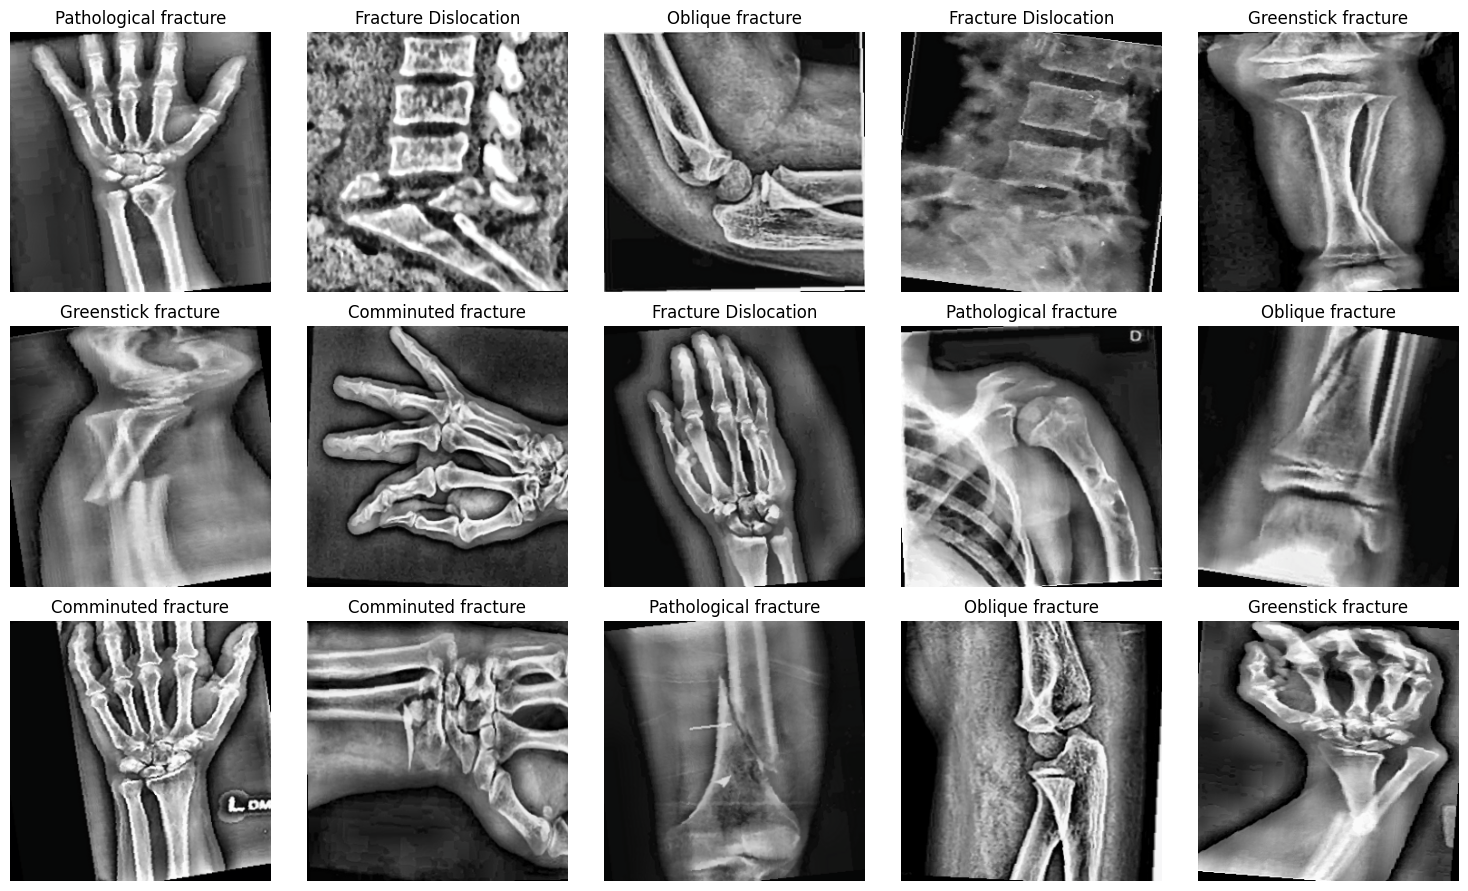

In [20]:
import random

def visualizar_ejemplos_por_clase(dataset, num_to_display=15, num_columnas=5):
    clases = dataset.classes

    # Get all indices for each class
    all_class_indices = {}
    for i in range(len(dataset)):
        _, label_idx = dataset.samples[i]
        if label_idx not in all_class_indices:
            all_class_indices[label_idx] = []
        all_class_indices[label_idx].append(i)

    # Initialize a list to hold the indices of images to plot
    images_to_plot_indices = []

    # Ensure each class appears at least once
    for label_idx in sorted(all_class_indices.keys()): # Sort keys for consistent ordering
        if all_class_indices[label_idx]:
            # Use pop(0) to get a unique one and remove it from the source list
            images_to_plot_indices.append(all_class_indices[label_idx].pop(0))

    # If we still need more images to reach num_to_display, fill them
    current_class_cycle_idx = 0
    class_keys = sorted(all_class_indices.keys())

    while len(images_to_plot_indices) < num_to_display:
        if not class_keys: # No more classes with remaining images
            break

        # Cycle through classes to add more images evenly
        class_to_draw_from = class_keys[current_class_cycle_idx % len(class_keys)]

        if all_class_indices[class_to_draw_from]:
            images_to_plot_indices.append(all_class_indices[class_to_draw_from].pop(0))
        else:
            # If a class runs out of images, remove it from consideration
            class_keys.remove(class_to_draw_from)
            if not class_keys: # No more classes left
                break
            # Adjust index so it doesn't skip the next class if current one was removed
            current_class_cycle_idx -= 1

        current_class_cycle_idx += 1

    # Shuffle the final list of indices for variety in display order
    random.shuffle(images_to_plot_indices)

    # Plotting
    display_count = len(images_to_plot_indices)
    num_filas = math.ceil(display_count / num_columnas)

    fig = plt.figure(figsize=(num_columnas * 3, num_filas * 3))

    # Iterate through the selected image indices to plot
    for idx_plot, img_dataset_idx in enumerate(images_to_plot_indices):
        img_tensor, label_idx = dataset[img_dataset_idx]

        # Desnormalizar para visualización
        img_display = img_tensor.permute(1, 2, 0).cpu().numpy()

        # Use mean and std from the notebook context. These were likely set for 3 channels.
        # Assuming mean and std are numpy arrays or lists that can be broadcasted
        # from the global variables `mean` and `std` defined earlier.
        global mean, std # Access global mean and std

        if isinstance(mean, list):
            mean_arr = np.array(mean)
        else:
            mean_arr = mean

        if isinstance(std, list):
            std_arr = np.array(std)
        else:
            std_arr = std

        img_display = img_display * std_arr + mean_arr
        img_display = np.clip(img_display, 0, 1)

        ax = plt.subplot(num_filas, num_columnas, idx_plot + 1)
        plt.imshow(img_display)
        plt.title(clases[label_idx])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function with the desired number of images to display
visualizar_ejemplos_por_clase(dataset_train, num_to_display=15)

### Entrenamiento fase 1 solo el clasificador

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = RadriografiaEfficientNetB2(num_classes=num_classes, freeze_backbone=True)

criterion = nn.CrossEntropyLoss()
parameters_to_optimize = filter(lambda p: p.requires_grad, model.parameters())
optimizer_f1 = torch.optim.Adam(parameters_to_optimize, lr=learning_rate, weight_decay=0.0001)

Usando dispositivo: cuda


In [34]:
print(model)

RadriografiaEfficientNetB2(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
         

In [35]:
history = train_model(model=model, train_loader=loader_train, val_loader=loader_test,
            criterion=criterion, optimizer=optimizer_f1, num_epochs=epochs_f1,
            save_best_model_path=save_best_model_path, save_historial_path=save_historial_path,
            device=device)

Época [1/20] | Train Loss: 1.7598 Acc: 0.2286 | Val Loss: 1.6442 Acc: 0.1940 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [2/20] | Train Loss: 1.4910 Acc: 0.3495 | Val Loss: 1.5191 Acc: 0.4030 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [3/20] | Train Loss: 1.4183 Acc: 0.4110 | Val Loss: 1.5027 Acc: 0.4179 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [4/20] | Train Loss: 1.3536 Acc: 0.4879 | Val Loss: 1.4550 Acc: 0.4030 
Época [5/20] | Train Loss: 1.3196 Acc: 0.5011 | Val Loss: 1.4463 Acc: 0.4478 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [6/20] | Train Loss: 1.2441 Acc: 0.5824 | Val Loss: 1.4165 Acc: 0.4776 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [7/20] | Train Loss: 1.2508 Acc: 0.5341 | Val Loss: 1.3987 Acc: 0.5224 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Époc

### Entrenamiento fase 2 descongelación de las 3 ultimas capas (fine-tuning)

In [36]:
for param in model.model.parameters():
    param.requires_grad = True

parameters_head = []
parameters_conv = []

for name, parameter in model.named_parameters():
    if name.startswith('model.classifier'):
        parameters_head.append(parameter)
    else:
        parameters_conv.append(parameter)

optimizer_f2 = torch.optim.Adam([
    {'params': parameters_conv, 'lr': 1e-6, 'weight_decay':0.0},
    {'params': parameters_head, 'lr': 1e-4, 'weight_decay': 1e-3}
])

In [37]:
model.load_state_dict(torch.load(save_best_model_path))

history_ft = train_model(model=model, train_loader=loader_train, val_loader=loader_test,
            criterion=criterion, optimizer=optimizer_f2, num_epochs=epochs_f2,
            save_best_model_path=save_best_model_path, save_historial_path=save_historial_path,
            device=device)

Época [1/40] | Train Loss: 1.0335 Acc: 0.6637 | Val Loss: 1.3177 Acc: 0.5373 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [2/40] | Train Loss: 1.0213 Acc: 0.6681 | Val Loss: 1.3174 Acc: 0.5672 **
Modelo guardado en: /content/checkpoints/radriografia_efficientnet_b2.h5
Época [3/40] | Train Loss: 0.9896 Acc: 0.6549 | Val Loss: 1.3141 Acc: 0.5224 
Época [4/40] | Train Loss: 0.9975 Acc: 0.6615 | Val Loss: 1.3149 Acc: 0.4925 
Época [5/40] | Train Loss: 0.9990 Acc: 0.6484 | Val Loss: 1.3110 Acc: 0.5075 
Época [6/40] | Train Loss: 0.9626 Acc: 0.6747 | Val Loss: 1.3107 Acc: 0.5373 
Época [7/40] | Train Loss: 1.0203 Acc: 0.6330 | Val Loss: 1.3130 Acc: 0.5075 
Época [8/40] | Train Loss: 0.9908 Acc: 0.6352 | Val Loss: 1.3067 Acc: 0.4925 
Época [9/40] | Train Loss: 1.0247 Acc: 0.6286 | Val Loss: 1.3105 Acc: 0.5224 
Época [10/40] | Train Loss: 1.0088 Acc: 0.6286 | Val Loss: 1.3049 Acc: 0.5373 
Época [11/40] | Train Loss: 0.9826 Acc: 0.6725 | Val Loss: 1.3106 Acc

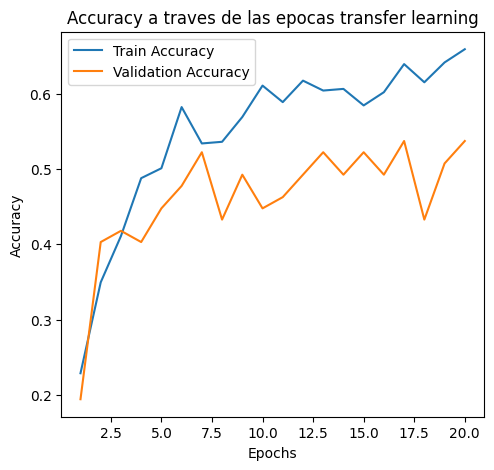

In [38]:
epochs_range = range(1, epochs_f1 + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy a traves de las epocas transfer learning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

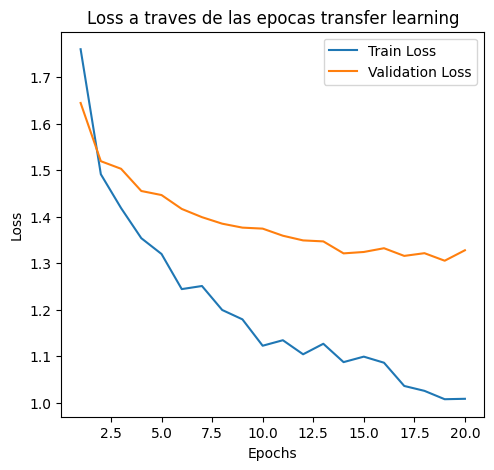

In [39]:
epochs_range = range(1, epochs_f1 + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.title('Loss a traves de las epocas transfer learning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

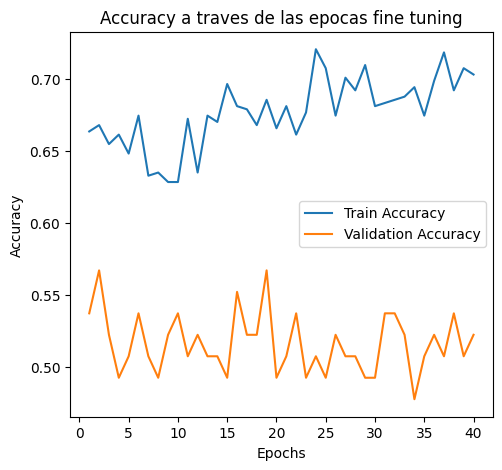

In [40]:
epochs_range = range(1, epochs_f2 + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_ft['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history_ft['val_acc'], label='Validation Accuracy')
plt.title('Accuracy a traves de las epocas fine tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

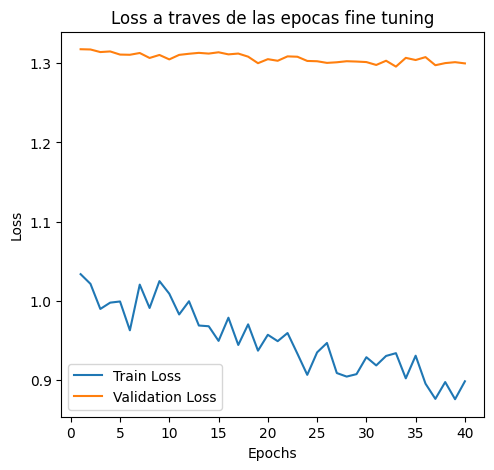

In [41]:
epochs_range = range(1, epochs_f2 + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_ft['train_loss'], label='Train Loss')
plt.plot(epochs_range, history_ft['val_loss'], label='Validation Loss')
plt.title('Loss a traves de las epocas fine tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

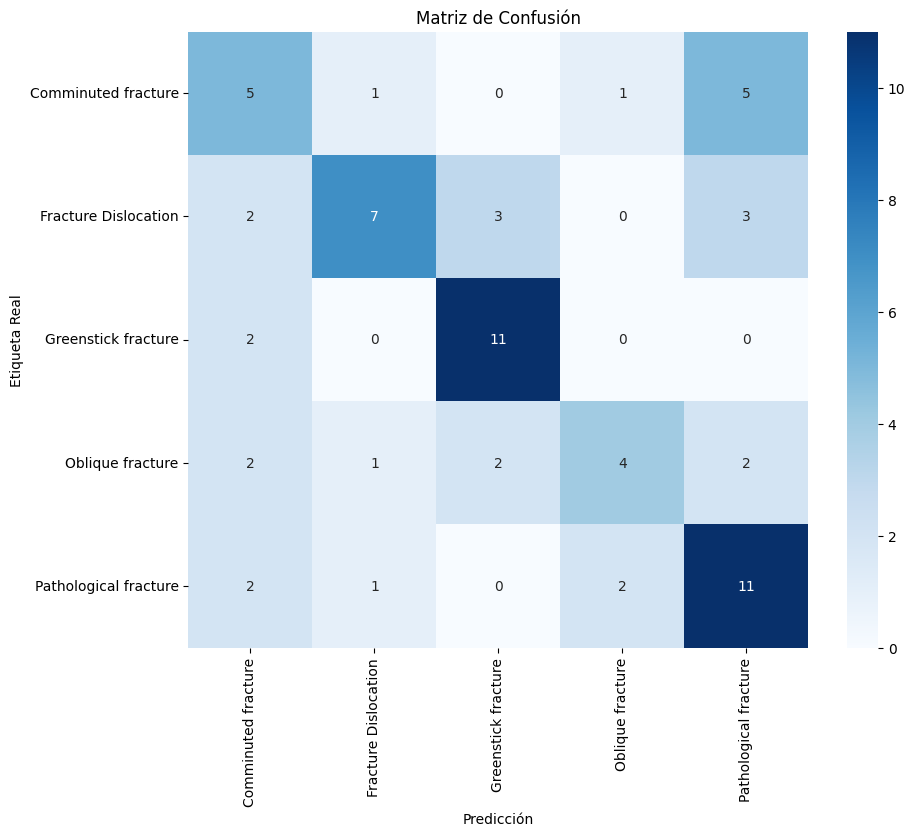

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, device, classes):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusión')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción')
    plt.show()

# Cargar los mejores pesos antes de evaluar
model.load_state_dict(torch.load(save_best_model_path))

# Graficar
clases_nombres = dataset_train.classes
plot_confusion_matrix(model, loader_test, device, clases_nombres)